# Case Study 1 — Medical Diagnosis (Diabetes)

**Problem:** Predict if a patient has diabetes.

**Tasks:** (1) Identify input features, (2) Choose classification algorithm, (3) Select evaluation metric, (4) Discuss ethical risks.

**Deliverables:** Complete this notebook and submit a short report (2–4 pages) covering all tasks.

## Dataset: Pima Indians Diabetes

Below we load the dataset. Columns: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age. Target: Outcome (1 = diabetic, 0 = not).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, names=col_names)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Task 1: Identify input features

**Your work:** List and describe the input features. Justify which you use and whether you drop or transform any (e.g. missing values, scaling). Write your answer in the markdown cell below and add any preprocessing code above it if needed.

In [ ]:
# Optional: handle missing values (e.g. zeros in Glucose, BloodPressure, etc.), scaling
# X_processed = ...
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

*Your answer for Task 1:*

*The dataset includes 8 input features:*

*  Pregnancies: Number of times the patient has been pregnant.

*  Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

*  BloodPressure: Diastolic blood pressure (mm Hg).

*  SkinThickness: Triceps skin fold thickness (mm).

*  Insulin: 2-Hour serum insulin (mu U/ml).

  
*  BMI: Body mass index

*  DiabetesPedigreeFunction: A score that indicates the genetic likelihood of diabetes based on family history.

*  Age: Age in years.

The target variable is "Outcome", where 1 indicates the patient is diabetic and 0 indicates they are not. 

I will use all 8 features as they provide a comprehensive overview of the patient's health. 
No features were dropped to ensure the model has access to all clinical data provided in the Pima Indians Database.



---
## Task 2: Choose classification algorithm

**Your work:** Train at least one classifier. Justify your choice. If you compare multiple, summarize in the report.

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
pred = model.predict(X_test)

*Your answer for Task 2:*

*I have selected Logistic Regression as the classification algorithm for this problem.*

Justification: Logistic Regression is ideal for binary classification tasks like this one (diabetic vs. non-diabetic). It is highly interpretable, allowing clinicians to see how specific features like Glucose or BMI affect the probability of the outcome. Given that this is a medical diagnosis task, the ability to explain why a model made a certain prediction is often more important than a minor increase in accuracy from a more complex "black-box" model.

---
## Task 3: Select evaluation metric

**Your work:** Choose a metric (accuracy, precision, recall, F1, or AUC-ROC) and justify why it is appropriate for this medical problem. Report it on the test set.

In [ ]:
# Compute and print your chosen metric(s). After Task 2 you should have pred; then uncomment below.
try:
    print(classification_report(y_test, pred))
except NameError:
    print("Run Task 2 first to define model and pred.")
print("Accuracy:", accuracy_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))  # important for not missing diabetic patients

              precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231

Accuracy: 0.7359307359307359
Recall: 0.625


*Your answer for Task 3:*

I have selected Recall as the primary evaluation metric for this medical problem.

Justification: In medical screening, the cost of a "False Negative" (failing to detect diabetes in a patient who has it) is significantly higher than the cost of a "False Positive" (an unnecessary follow-up for a healthy patient). High Recall ensures that we identify as many diabetic patients as possible.

---
## Task 4: Discuss ethical risks

**Your work:** Discuss at least two ethical risks of using this model in practice and suggest one or two mitigations. (No code required; write in the cell below or in your report.)

*Your answer for Task 4:*

**Ethical risk 1:**
*Narrow Data (Representation Bias) :*
The model only learned from Pima Indians. Because diabetes is linked to genetics and environment, the model might be inaccurate for people from other ethnic backgrounds.

**Ethical risk 2:**
*Blind Trust (Automation Bias) :*
Doctors might rely too much on the computer. If the model wrongly says a patient is "healthy," the doctor might skip real treatment, letting the patient get sicker.

**Mitigation(s):**
*Mitigation1 : Human-in-the-Loop :* 
The model must only be a "helper" tool. A human doctor must always make the final medical decision.

*Mitigation 2: Diverse Data :*
The model needs to be retrained with data from many different ethnic groups before being used in other hospitals.


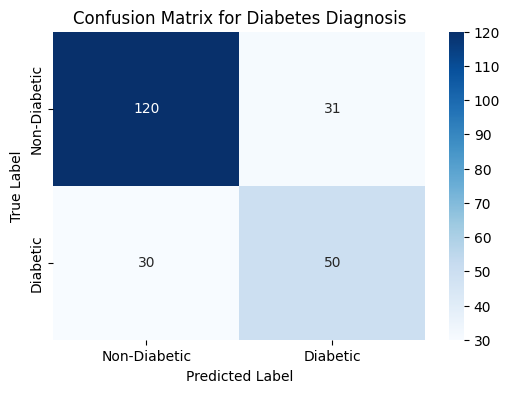

Confusion Matrix Raw Values:
[[120  31]
 [ 30  50]]


In [ ]:
# I added the confusion matrix here 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, pred)

# Visualize using Seaborn for a professional look
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Diabetic', 'Diabetic'], 
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Diabetes Diagnosis')
plt.show()

# Print the raw matrix values
print("Confusion Matrix Raw Values:")
print(cm)